In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import gdown

file_id = '1QBQ3J1oXqjjAjxAvOLBMiXmZ-MjKi4YS'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'data.csv', quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1QBQ3J1oXqjjAjxAvOLBMiXmZ-MjKi4YS
To: /content/data.csv
100%|██████████| 4.21M/4.21M [00:00<00:00, 31.9MB/s]


'data.csv'

In [ ]:
dataset = pd.read_csv('data.csv' , lineterminator='\n')
dataset.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [ ]:
dataset.duplicated().sum()

np.int64(0)

In [ ]:
dataset.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


Exporation Summary


*   We have dataset having 0 to 9826 i.e 9827 data / Rows.

*    Our dataset appears well-structured, free from NaN values and  
     duplicates, ensuring a clean and professional presentation.

*    Release Date column needs to be casted into date time and to extract only the year value.
*   Overview, Original_Languege and Poster-Url wouldn't be so useful during analysis, so we'll drop them.


*   There is noticable outliers in Popularity column.

*   Vote_Average bettter be categorised for proper analysis.


*   Genre column has comma saperated values and white spaces that needs to be handled and casted into category.









In [ ]:
#Convert Release_Date into datetime and extract only
dataset['Release_Date'] = pd.to_datetime(dataset['Release_Date'])
print(dataset['Release_Date'].dtypes)


datetime64[ns]


In [ ]:
dataset['Release_Date'] = dataset['Release_Date'].dt.year
print(dataset['Release_Date'].dtypes)

int32


In [ ]:
dataset.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [ ]:
dataset = dataset.rename(columns={'Release_Date':'Release_Year'})

In [ ]:
dataset.head()

,Release_Year,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [ ]:
#remove the unnecessary column
dataset.drop(['Overview','Original_Language','Poster_Url'],axis=1,inplace=True)

In [ ]:
dataset.head()

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [ ]:
def Catigorize_col(df , col , label):
  edges = [df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max'],
          ]
  df[col] = pd.cut(df[col],edges, labels=label , duplicates= 'drop')
  return df

**categorizing** **Vote_Average** **column**
*   We would cut the Vote_Average values and make 4 categories: popular ,average, below_avg and not_popular to describe it more using catigorize_col() function
provided above.





In [ ]:
dataset['Movie_Rating']= dataset['Vote_Average']

In [ ]:
dataset.head()

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre,Movie_Rating
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",8.3
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",8.1
2,2022,No Exit,2618.087,122,6.3,Thriller,6.3
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",7.7
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",7.0


In [ ]:
label = ['not_popular','below_avg','average','popular']
Catigorize_col(dataset , 'Movie_Rating' , label)

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre,Movie_Rating
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",popular
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",popular
2,2022,No Exit,2618.087,122,6.3,Thriller,below_avg
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",popular
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",average
...,...,...,...,...,...,...,...
9822,1973,Badlands,13.357,896,7.6,"Drama, Crime",popular
9823,2020,Violent Delights,13.356,8,3.5,Horror,not_popular
9824,2016,The Offering,13.355,94,5.0,"Mystery, Thriller, Horror",not_popular
9825,2021,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History",average


In [ ]:
dataset.head()

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre,Movie_Rating
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",popular
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",popular
2,2022,No Exit,2618.087,122,6.3,Thriller,below_avg
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",popular
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",average


In [ ]:
dataset['Movie_Rating'].value_counts()

,count
Movie_Rating,
not_popular,2467
popular,2450
average,2412
below_avg,2398


In [ ]:
dataset.isnull().sum()

,0
Release_Year,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0
Movie_Rating,100


In [ ]:
dataset.dropna(inplace=True)

dataset.isna().sum()

,0
Release_Year,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0
Movie_Rating,0


In [ ]:
dataset['Genre'] = dataset['Genre'].str.split(', ')

dataset = dataset.explode('Genre').reset_index(drop= True)

In [ ]:
dataset.head()

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre,Movie_Rating
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,Mystery,popular


In [ ]:
# Casting column into category type
dataset['Genre'] = dataset['Genre'].astype('category')

In [ ]:
dataset['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Year  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  float64 
 5   Genre         25552 non-null  category
 6   Movie_Rating  25552 non-null  category
dtypes: category(2), float64(2), int32(1), int64(1), object(1)
memory usage: 949.2+ KB


In [ ]:
dataset.nunique()

,0
Release_Year,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,73
Genre,19
Movie_Rating,4


# **Data** **Visualization**

In [ ]:
sns.set_style('whitegrid')

# **What** **is** **the** **most** **frequent** **genre** **of** **movies** **released** **on** **netflix** **?**

In [ ]:
dataset['Genre'].describe()

,Genre
count,25552
unique,19
top,Drama
freq,3715


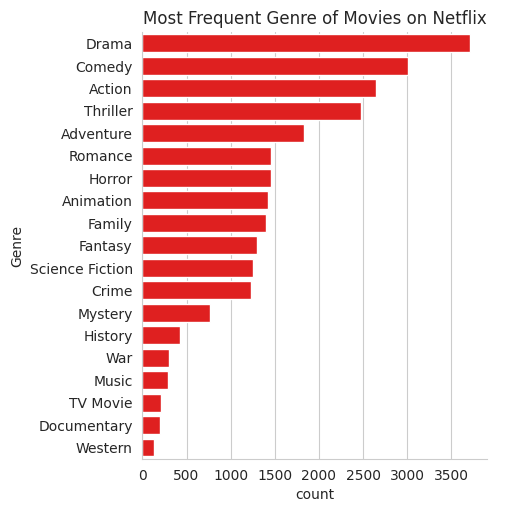

In [ ]:
sns.catplot( y = 'Genre' , data = dataset , kind = 'count' ,order = dataset['Genre'].value_counts().index , color='red')
plt.title('Most Frequent Genre of Movies on Netflix')
plt.show()

# **Which** **has** **highest** **Votes** **in** **vote_avg** **column** **?**

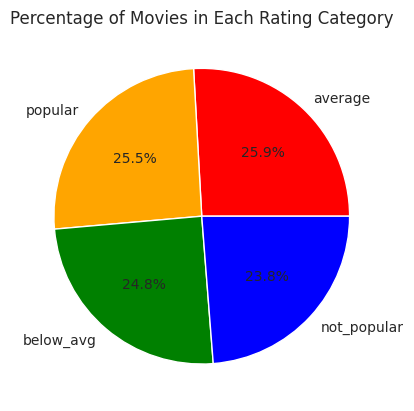

In [ ]:
colors = {
    "not_popular": "red",
    "below_avg": "orange",
    "average": "green",
    "popular": "blue"
}
dataset["Movie_Rating"].value_counts().plot.pie(autopct="%1.1f%%", colors=colors.values())
plt.title("Percentage of Movies in Each Rating Category")
plt.ylabel("")  # Hide y-label for cleaner look
plt.show()

# **Which** **Movie** **Got** **Highest** **popularity** **?** **what's** **it's genre** **?**

In [ ]:
dataset[dataset['Popularity'] == dataset['Popularity'].max()]

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre,Movie_Rating
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular


# **Which** **Movie** **Got** **Lowest** **popularity ?** **what's it's genre ?**

In [ ]:
dataset[dataset['Popularity'] == dataset['Popularity'].min()]

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Genre,Movie_Rating
25546,2021,The United States vs. Billie Holiday,13.354,152,6.7,Music,average
25547,2021,The United States vs. Billie Holiday,13.354,152,6.7,Drama,average
25548,2021,The United States vs. Billie Holiday,13.354,152,6.7,History,average
25549,1984,Threads,13.354,186,7.8,War,popular
25550,1984,Threads,13.354,186,7.8,Drama,popular
25551,1984,Threads,13.354,186,7.8,Science Fiction,popular


# **Which Movie year is most flimmed movie ?**

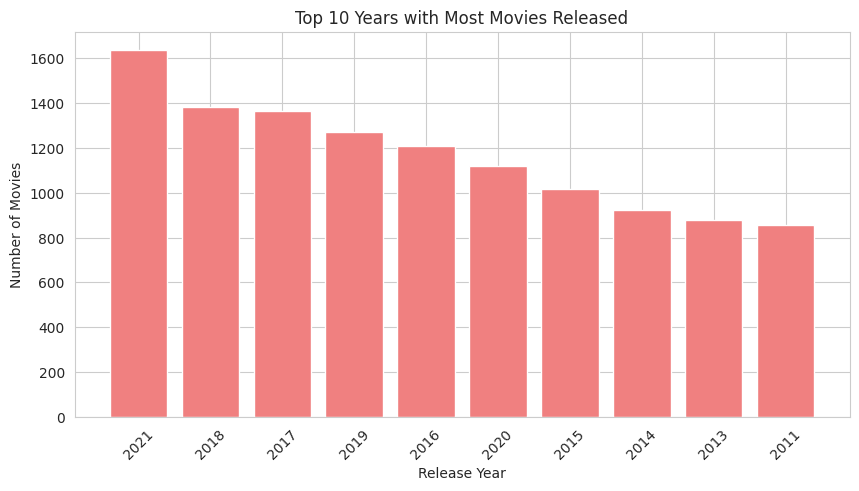

In [ ]:
Movie_Year = dataset['Release_Year'].value_counts().reset_index()
Movie_Year.columns = ['Release_Year','Movie_Count']
Movie_Year = Movie_Year.nlargest(10,'Movie_Count')
Movie_Year

plt.figure(figsize=(10, 5))
plt.bar(Movie_Year['Release_Year'].astype(str), Movie_Year['Movie_Count'], color='lightcoral')

# Labels and title
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.title('Top 10 Years with Most Movies Released')
plt.xticks(rotation=45)

# Show the plot
plt.show()

In [ ]:
!pip install dash dash-bootstrap-components plotly pandas

In [ ]:
import dash
from dash import dcc, html
import dash_bootstrap_components as dbc
import plotly.express as px

In [ ]:

# Data Processing
Movie_Year = dataset['Release_Year'].value_counts().reset_index()
Movie_Year.columns = ['Release_Year', 'Movie_Count']
Movie_Year = Movie_Year.nlargest(10, 'Movie_Count').sort_values(by='Movie_Count', ascending=False)

genre_counts = dataset['Genre'].value_counts().reset_index()
movie_ratings = dataset['Movie_Rating'].value_counts()

most_popular = dataset.loc[dataset['Popularity'].idxmax()]
most_popular_genre= dataset[dataset['Popularity']==dataset['Popularity'].max()]['Genre'].unique()
most_popular_genre = ", ".join(most_popular_genre)
least_popular = dataset.loc[dataset['Popularity'].idxmin()]
title = dataset[dataset['Popularity']==dataset['Popularity'].min()]['Title'].unique()
title = " and ".join(title)
least_popular_genre= dataset[dataset['Popularity']==dataset['Popularity'].min()]['Genre'].unique()
least_popular_genre = ", ".join(least_popular_genre)


# Initialize Dash App
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])

# Define a common dark theme layout for all graphs
dark_theme_layout = {
    "plot_bgcolor": "#222222",  # Dark background for the plot area
    "paper_bgcolor": "#222222",  # Dark background for the entire graph
    "font": {"color": "white"}  # White text for readability
}

# Layout
app.layout = dbc.Container([
    html.H1("Netflix Data Analysis Dashboard", className="text-center text-danger mb-4"),

    dbc.Row([
        dbc.Col(dcc.Graph(
            figure=px.bar(genre_counts, x=genre_counts.index, y='Genre', title="Most Frequent Movie Genres",
                          labels={'index': 'Genre', 'Genre': 'Count'},
                          color_discrete_sequence=['red']).update_layout(**dark_theme_layout)
        ), width=7),

        dbc.Col(dcc.Graph(
            figure=px.pie(names=movie_ratings.index, values=movie_ratings.values,
                          title="Movie Rating Distribution",
                          color_discrete_sequence=['red', 'darkred', 'crimson', 'lightcoral']).update_layout(**dark_theme_layout)
        ), width=5),
    ]),

    dbc.Row([
        dbc.Col(dcc.Graph(
            figure=px.bar(Movie_Year, x=Movie_Year['Release_Year'].astype(str), y='Movie_Count',
                          title="Top 10 Years with Most Movies Released",
                          labels={'x': 'Years', 'Movie_Count': 'Movies'},
                          color_discrete_sequence=['red']).update_layout(**dark_theme_layout)
        ), width=12),
    ]),

    dbc.Row([
        dbc.Col(dbc.Card([
            dbc.CardHeader("Most Popular Movie"),
            dbc.CardBody([
                html.H5(most_popular['Title']),
                html.P(),
                html.P(f"Popularity Score: {most_popular['Popularity']}"),
                html.P(f" Genre : {most_popular_genre}")

            ])
        ], color="success", inverse=True), width=6 , style={"margin-bottom": "50px", "margin-top":"50px"}),

        dbc.Col(dbc.Card([
            dbc.CardHeader("Least Popular Movie"),
            dbc.CardBody([
                html.H5(title),
                html.P(),
                html.P(f"Popularity Score: {least_popular['Popularity']}"),
                html.P(f" Genre : {least_popular_genre}")
            ])
        ], color="danger", inverse=True), width=6 , style={"margin-bottom": "50px", "margin-top":"50px"}),
    ]),
    dbc.Row([])
], fluid=True)

# Run App
if __name__ == '__main__':
    app.run(debug=True)




<IPython.core.display.Javascript object>

Q-1: What is the most frequent genre in the dataset?

Drama genre is the most frequent genre in our dataset and has appeared
more than 14% of the times among 19 other genres.



---



Q-2: What genres has highest votes ?

we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the highest popularity among fans by being having more than 18.5% of movies popularities.



---


Q-3: What movie got the highest popularity? what's its genre ?

Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action, Adventure and Sience Fiction.



---

Q-4: What movie got the lowest popularity? what's its genre ?

The United States vs. Billie Holiday and Threads has the lowest rate in our dataset and it has genres of music, drama, war, science-fiction and history.



---


Q-5: Which year has the most filmmed movies?

year 2021 has the highest filmming movies in our dataset.